# Programming Assignment 1  
## Performance Comparison: Pure Python vs NumPy

### Objective

The goal of this experiment is to compare the execution time of:

1. Pure Python implementations using explicit loops.
2. NumPy implementations using vectorized operations.

The comparison includes:
- 1-D element-wise vector multiplication.
- 2-D true matrix multiplication.

We measure execution time and compute speedup.

## Measurement Protocol

To ensure fair comparison:

- Arrays are created outside the timed region.
- Only the multiplication operation is timed.
- One warm-up run is executed per size.
- Multiple trials are performed and the median runtime is reported.
- A fixed random seed is used for reproducibility.
- All data uses dtype float64.

## Libraries Needed

- `time`: To take the time of execution
- `numpy`: baseline to compare between the pure python code
- `matplotlib`: To plot the results into structured graphs

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

## Timing Setup and Reproducibility

This section initializes the benchmarking environment.

- A fixed random seed is set to ensure reproducibility of experiments.

- The function `median_time()` is defined to measure execution time of any function:
  - One warm-up run is executed to stabilize system effects.
  - Multiple trials are performed.
  - The median runtime is returned to reduce the effect of timing noise.

This follows the experimental protocol required for fair performance comparison.

In [2]:
# Initialize the random number generator with a fixed seed (reproducibility)
np.random.seed(0)

# Function to measure execution time using multiple trials
def median_time(func, *args, trials=15, warmup=1):
    # Warm-up runs (not timed)
    for i in range(warmup):
        func(*args)

    # List to store execution times of each trial
    times = []
    # Perform multiple timed executions
    for i in range(trials):
        # Start high-resolution timer
        t0 = time.perf_counter()
        # Execute the function being benchmarked
        func(*args)
        # Stop timer
        t1 = time.perf_counter()
        # Store elapsed time for this trial
        times.append(t1 - t0)

    # Return the median runtime
    return float(np.median(times))

## 1-D Element-wise Multiplication

We implement element-wise vector multiplication in:

- Pure Python using explicit loops.
- NumPy using vectorized operations.

In [3]:
# Pure Python function of element-wise vector multiplication
def py_elementwise(a, b):
    # Pre-allocate output list with zeros (same length as input)
    out = [0.0] * len(a)
    # Loop through each index of the vectors for multiply and store the results
    for i in range(len(a)):
        out[i] = a[i] * b[i]
    # Return resulting list
    return out

# NumPy function of element-wise vector multiplication
def np_elementwise(a, b):
    # Vectorized multiplication
    return a * b

In [4]:
# 1-D Arrays (Vectors)
vector_sizes = [10, 50, 100, 200, 500]

# Lists to store median runtimes for each method
py_times_1d = []
np_times_1d = []

# Loop over each vector size
for n in vector_sizes:
    # Generate random vector as Python list 
    a_list = np.random.rand(n).tolist()
    b_list = np.random.rand(n).tolist()

    # Convert lists to NumPy arrays
    a_np = np.array(a_list, dtype=np.float64)
    b_np = np.array(b_list, dtype=np.float64)

    # Correctness Verification (np.allclose())
    assert np.allclose(py_elementwise(a_list, b_list),
                       np_elementwise(a_np, b_np))

    # Measure execution time for pure Python implementation
    t_py = median_time(py_elementwise, a_list, b_list)
    # Measure execution time for NumPy implementation
    t_np = median_time(np_elementwise, a_np, b_np)

    # Store measured times
    py_times_1d.append(t_py)
    np_times_1d.append(t_np)


# Print formatted performance comparison results
for n, t1, t2 in zip(vector_sizes, py_times_1d, np_times_1d):
    # Display runtime and computed speedup
    print(f"n={n:>4} | Python={t1:.6e} s | NumPy={t2:.6e} s | Speedup={t1/t2:.2f}x")

n=  10 | Python=9.000069e-07 s | NumPy=9.000069e-07 s | Speedup=1.00x
n=  50 | Python=3.799971e-06 s | NumPy=1.000008e-06 s | Speedup=3.80x
n= 100 | Python=7.199997e-06 s | NumPy=1.000008e-06 s | Speedup=7.20x
n= 200 | Python=1.419999e-05 s | NumPy=8.000061e-07 s | Speedup=17.75x
n= 500 | Python=2.059998e-05 s | NumPy=5.000038e-07 s | Speedup=41.20x


## 2-D True Matrix Multiplication

We implement matrix multiplication:

- Pure Python using triple nested loops.
- NumPy using the `@` operator.

This demonstrates the performance difference between interpreted loops and compiled numerical libraries.

In [5]:
# Pure Python function of true matrix multiplication
def py_matmul(A, B):
    # Number of rows of matrix A
    n = len(A)
    # Number of columns of matrix B
    m = len(B[0])
    # Shared dimension (columns of A = rows of B)
    p = len(B)
    # Pre-allocate result matrix C (n x m) filled with zeros
    C = [[0.0 for _ in range(m)] for _ in range(n)]

    # Loop over rows of A
    for i in range(n):
        # Loop over columns of B
        for j in range(m):
            # Accumulator for dot product
            s = 0.0
            # Compute dot product between row i of A and column j of B
            for k in range(p):
                s += A[i][k] * B[k][j]
            # Store computed value in result matrix
            C[i][j] = s
            
    # Return resulting matrix
    return C


# NumPy function of matrix multiplication
def np_matmul(A, B):
    # Perform matrix multiplication using optimized NumPy routine
    return A @ B

In [6]:
# Matrix sizes to evaluate scalability
matrix_sizes = [10, 50, 100, 200, 500]

# Lists to store median runtimes
py_times_2d = []
np_times_2d = []

# Loop through each matrix size
for n in matrix_sizes:
    # Generate random matrices as Python lists (for pure Python version)
    A_list = np.random.rand(n, n).tolist()
    B_list = np.random.rand(n, n).tolist()

    # Convert lists to NumPy arrays with consistent dtype
    A_np = np.array(A_list, dtype=np.float64)
    B_np = np.array(B_list, dtype=np.float64)

    # Compute results once to verify correctness
    C_py = py_matmul(A_list, B_list)
    C_np = np_matmul(A_np, B_np)

    # Correctness Verification (np.allclose())
    assert np.allclose(np.array(C_py), C_np)

    # Measure execution time for pure Python triple-loop implementation
    t_py = median_time(py_matmul, A_list, B_list)
    # Measure execution time for NumPy matrix multiplication
    t_np = median_time(np_matmul, A_np, B_np)

    # Store measured times
    py_times_2d.append(t_py)
    np_times_2d.append(t_np)


# Print formatted performance comparison results
for n, t1, t2 in zip(matrix_sizes, py_times_2d, np_times_2d):
    # Display runtime and computed speedup
    print(f"n={n:>4} | Python={t1:.6e} s | NumPy={t2:.6e} s | Speedup={t1/t2:.2f}x")

n=  10 | Python=8.949998e-05 s | NumPy=1.800014e-06 s | Speedup=49.72x
n=  50 | Python=9.292100e-03 s | NumPy=6.499991e-06 s | Speedup=1429.56x
n= 100 | Python=6.030800e-02 s | NumPy=2.430001e-05 s | Speedup=2481.81x
n= 200 | Python=4.708308e-01 s | NumPy=1.060000e-04 s | Speedup=4441.80x
n= 500 | Python=7.763448e+00 s | NumPy=1.557900e-03 s | Speedup=4983.28x


## Performance Results

We visualize median runtime as a function of input size.
Log scale is used to better observe growth trends.

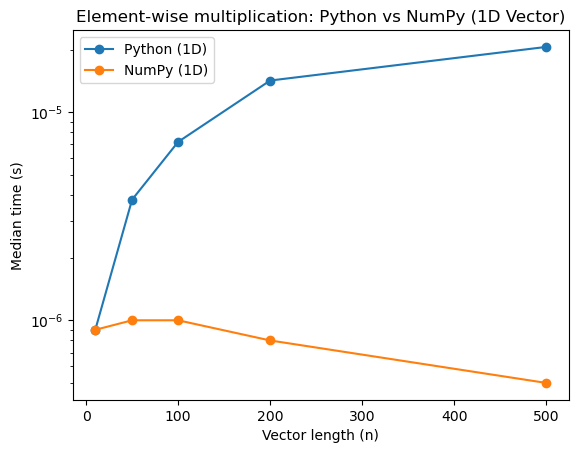

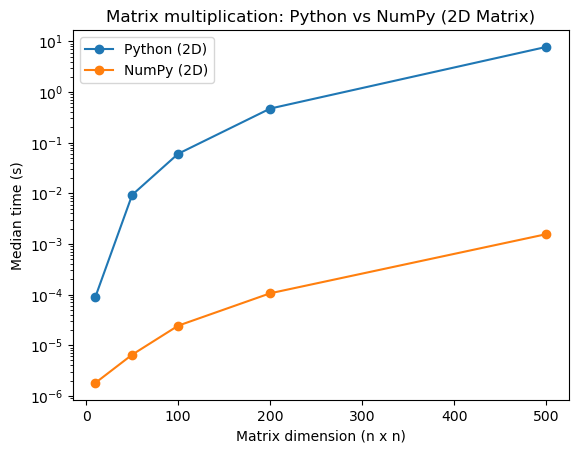

In [8]:
# Plot 1D performance comparison (Vector element-wise)
plt.figure()
plt.plot(vector_sizes, py_times_1d, marker='o', label='Python (1D)')
plt.plot(vector_sizes, np_times_1d, marker='o', label='NumPy (1D)')
plt.xlabel("Vector length (n)")
plt.ylabel("Median time (s)")
plt.title("Element-wise multiplication: Python vs NumPy (1D Vector)")
plt.legend()
plt.yscale("log")
plt.savefig("performance_1D_vector.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 2D performance comparison (Matrix multiplication)
plt.figure()
plt.plot(matrix_sizes, py_times_2d, marker='o', label='Python (2D)')
plt.plot(matrix_sizes, np_times_2d, marker='o', label='NumPy (2D)')
plt.xlabel("Matrix dimension (n x n)")
plt.ylabel("Median time (s)")
plt.title("Matrix multiplication: Python vs NumPy (2D Matrix)")
plt.legend()
plt.yscale("log")
plt.savefig("performance_2D_matrix.png", dpi=300, bbox_inches="tight")
plt.show()